<a href="https://colab.research.google.com/github/gugazan/MVP-Machine-Learning-e-Analytics/blob/main/MVP_Machine_Learning_e_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Machine Learning e Analytics

**Nome**: Gustavo Carvalho da Silva Pampillón Rodrigues

**Matrícula**: 4052025001253

<a href="https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data">Dataset: Bitcoin Historical Data</a>

# 1 - Escopo, Objetivo e Definição do Problema

- Neste notebook vamos trabalhar com um dataset que mostra o preço do Bitcoin minuto a minuto de um período desde 2012, até 2025. Cada instância mostra o momento, que age como identificador, preço de abertura, preço mais alto, preço mais baixo e preço de fechamento e por fim o volume total de bitcoin negociado naquele intervalo.

- O objetivo aqui vai ser a implementação de um modelo de forecasting via série temporal para prever o preço do bitcoin no minuto T+1. Aprendizado suoervisionado via regressão

- Estaremos aplicando dados tabulares para implementar modelos de regressão que possam aproximar da melhor forma o preço futuro da moeaa.

- Esse tipo de problema tem alto valor para o usuário, literalmente, pois se aplicado de forma precisa pode gerar ganhos financeiros. É claro que criptomoedas como é o caso da bitcoin são também muito afetadas por situações e políticas do mundo externo, mas em condições normais de temperatura e pressão a ideia é gerar uma previsão que faça sentido financeiramente para o usuário.

# 1.1 - Notas
- Preferi deixar as funções definidas ao longo do notebook mesmo pois achei que dessa forma fica mais claro onde elas estão sendo usadas. Além disso foi mais prático de ajusta-las quando elas estavam perto do seu uso onde podia analisar os resultados

- Ao longo do dataset fiz diversos ajustes para lidar melhor com o consumo de RAM

- O dataset tem apenas dados tabulares não categóricos, logo não foi preciso fazer nenhum transformação nos dados, como OneHotEnconding, e também pelo contexto não foi necessária nenhuma normalização ou transformação do tipo

# 2- Importação das Bibliotecas, Carga de Dados e Reprodutiblidade

Esta seção consolida todas as importações de bibliotecas necessárias para o projeto assim como a definição de SEED fixa para reprodutibilidade.
Aqui também vai ser feito a carga e setup do dataset.
O tamanho dos dados excedia o limite de 100mb do Github, então usei a ferramenta [git lfs](https://git-lfs.com/) para lidar com o problema.

# 2.1- Imports + Seed

In [50]:
# === Imports principais ===
import os, random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor

# === Seeds para reprodutibilidade ===
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Leitura em chunks
READ_IN_CHUNKS = True
CHUNK_SIZE = 1_000_000

# Corte temporal: 2017+
CUTOFF_TS = pd.Timestamp("2017-01-01", tz="UTC")
CUTOFF_UNIX = int(CUTOFF_TS.timestamp())

# Perfis de treino
N_TRAIN_SUB = 500_000
SUB_B_LITE  = 150_000

# Warm-up (janelas/rollings)
WARMUP = 60


#2.2 - Carga de Dados
(Pode levar até 30s aproximadamente)

In [51]:
CSV_URL = "https://media.githubusercontent.com/media/gugazan/MVP-Machine-Learning-e-Analytics/refs/heads/main/files/btcusd_1-min_data.csv"


def read_csv(url: str, chunksize: int = 1_000_000):
    usecols = ["Timestamp","Open","High","Low","Close","Volume"]
    dtypes  = {"Timestamp":"float64","Open":"float32","High":"float32","Low":"float32","Close":"float32","Volume":"float32"}
    dfs = []
    for chunk in pd.read_csv(url, usecols=usecols, dtype=dtypes, chunksize=chunksize):
        sub = chunk.loc[chunk["Timestamp"] >= CUTOFF_UNIX].copy()
        if sub.empty:
            continue
        sub.columns = [re.sub(r"\W+","_", c).lower() for c in sub.columns]
        sub["timestamp"] = pd.to_datetime(sub["timestamp"], unit="s", errors="coerce")
        sub = sub.dropna(subset=["timestamp"])
        dfs.append(sub)
    return pd.concat(dfs, ignore_index=False)

if READ_IN_CHUNKS:
    df = read_csv(CSV_URL, chunksize=CHUNK_SIZE)
else:
    df = pd.read_csv(CSV_URL)
    expected = {"Timestamp","Open","High","Low","Close","Volume"}
    if not expected.issubset(set(df.columns)):
        df = pd.read_csv(CSV_URL, header=0)
        if not expected.issubset(set(df.columns)):
            df = pd.read_csv(CSV_URL, header=None, names=["Timestamp","Open","High","Low","Close","Volume"])
    df.columns = [re.sub(r"\W+","_", str(c).strip()).lower() for c in df.columns]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
    df = df.loc[df["timestamp"] >= pd.Timestamp("2017-01-01")]

# Indexar, regularizar frequência de 1 min e preencher
df = df.sort_values("timestamp").set_index("timestamp").asfreq("min")
for c in ["open","high","low","close","volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").ffill().bfill().astype("float32")

print("Faixa:", df.index.min(), "→", df.index.max(), "| Linhas:", len(df))
display(df.head(3))


Faixa: 2017-01-01 00:00:00 → 2025-09-23 23:57:00 | Linhas: 4590718


,open,high,low,close,volume
timestamp,,,,,
2017-01-01 00:00:00,963.159973,963.159973,963.159973,963.159973,0.000000
2017-01-01 00:01:00,962.849976,962.849976,962.849976,962.849976,0.028129
2017-01-01 00:02:00,962.849976,962.849976,962.849976,962.849976,0.000000


- Aqui é feito um downcast do tipo de dado para float32, assim consigo admnistra o quanto de memória estou usando e pela natureza dos dados não vou precisar de um valor maior do que esse tipo permite

- Inicialmente tive bastante problemas com a memória do colab, então após gerar o gráfico abaixo resolvi voltar atrás no código e remover tudo que veio antes de 2017, para ter um volume de dados "menor"

- Também implementei a leitura do dataset em chunks pelo mesmo motivo

- Com a retirada desses 5 anos de dados com pouca variação que foram retirados retirei 2630279 instâncias do dataset

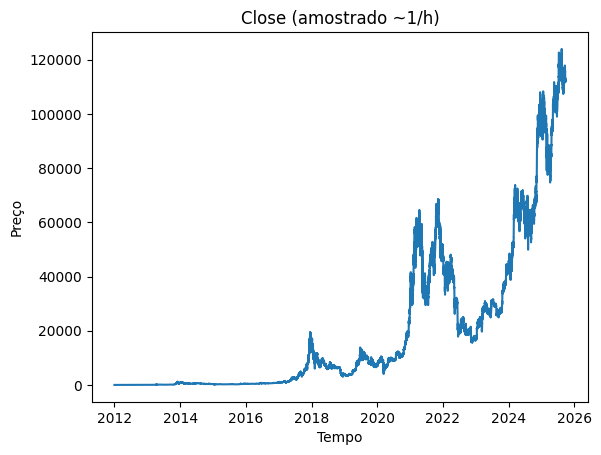

# 3- Análise Exploratório dos Dados
Como esse não é o foco desse MVP, fiz uma EDA um pouco mais enxuta, especialmente se comparada com a sprint de boas práticas.

In [52]:
display(df.describe().round(3))

,open,high,low,close,volume
count,4590718.000,4590718.000,4590718.000,4590718.000,4590718.000
mean,31451.158,31462.588,31439.416,31451.182,4.187
std,30267.385,30274.768,30259.818,30267.381,12.774
min,752.000,752.810,751.340,752.040,0.000
25%,7864.172,7870.000,7857.700,7864.152,0.080
50%,20579.830,20586.825,20572.239,20580.000,0.627
75%,47123.479,47145.000,47101.000,47124.425,3.126
max,124479.000,124517.000,124321.000,124482.000,1616.060


- O dataset escolhido tem 7220997 instâncias e abrange um perído desde 01/01/2012 até 23/09/2025, porém foi feito um recorte de 2017+ para frente, para lidar com menos dados e dados mais interessantes (maior variação)

- Com o `describe()` podemos ver que o valor médio do bitcoin é na casa dos 20 mil dólares, porém com um desvio padrão bem alto, em torno de 28 mil dólares. De fato essa informação se confirma com o que sabemos sobre a alta flutuação de criptomoedas.

- Aqui também podemos observar a baixa e alta histórica, sendo respecitvamente:
3,80  dólares e ~124 mil dólares.

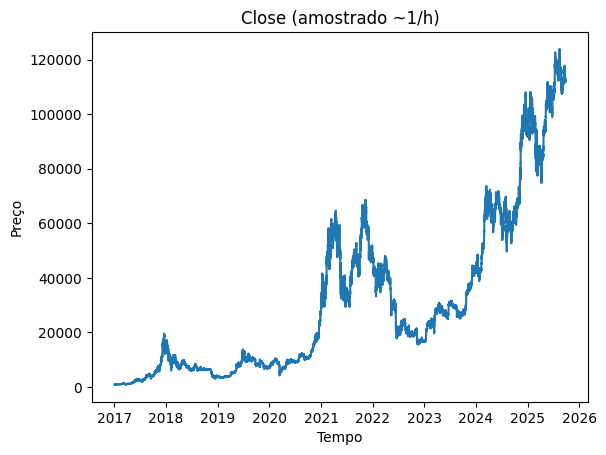

In [53]:
plt.figure()
plt.plot(df.index[::60], df["close"].iloc[::60])
plt.title("Close (amostrado ~1/h)")
plt.xlabel("Tempo"); plt.ylabel("Preço")
plt.show()


Gráfico histórico do valor de fechamento do bitcoin

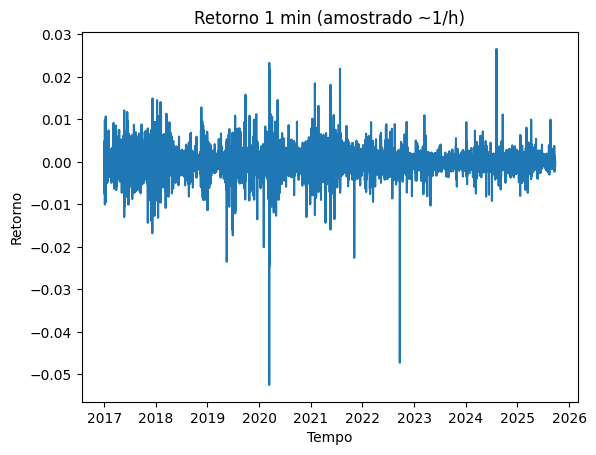

In [54]:
# Calcula o retorno percentual de 1 minuto
# (close_t - close_{t-1}) / close_{t-1}
df["ret_1m"] = df["close"].pct_change()
plt.figure()
plt.plot(df.index[::60], df["ret_1m"].fillna(0).iloc[::60])
plt.title("Retorno 1 min (amostrado ~1/h)")
plt.xlabel("Tempo"); plt.ylabel("Retorno")
plt.show()


- Esse gráfico serve para visualizar o retorno de acordo com a variância minuto a minuto, ou seja, quanto eu lucrei em média em cada minuto.

- Podemos observar que existe uma perda muito significativa, que no geral se aproxima dos ganhos.

#4-  Split temporal
- Nessa etapa vamos essencialmete dividir os dados em treino e teste, mas respeitando a sequência temporal correta.

- O alvo close_t1 vai ser usado na baseline do Naive Last Value. Aqui também foi criado o close_t5, para os modelos de árvore.

In [55]:
n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_valid = df.iloc[train_end:valid_end].copy()
df_test  = df.iloc[valid_end:].copy()

for part in (df_train, df_valid, df_test):
    part["close_t1"] = part["close"].shift(-1)
    part["close_t5"] = part["close"].shift(-5)

print(
    f"Tamanhos:\n"
    f" - Treino:    {len(df_train):,}\n"
    f" - Validação: {len(df_valid):,}\n"
    f" - Teste:     {len(df_test):,}\n"
)


Tamanhos:
 - Treino:    3,213,502
 - Validação: 688,608
 - Teste:     688,608



- Aqui dividimos o dataset em treino, validação e teste. Criamos a variável alvo close_t1 e close_t5 para prever o minuto seguinte do preço.

- Usando um split temporal evitamos *data leakage* pois o modelo estaria aprendendo com seu próprio futuro.

- Com a divisão de validação vamos poder ajusar os hiperparametros no futuro.

# 5 - Feature Engineering

In [56]:
def make_features(frame, lags=(1,2,3,5,10), windows=(5,15,30,60)):
    out = frame.copy()
    for base in ["open","high","low","close","volume"]:
        for L in lags:
            out[f"{base}_lag{L}"] = out[base].shift(L)
    for W in windows:
        out[f"close_roll{W}_mean"] = out["close"].rolling(W).mean()
        out[f"close_roll{W}_std"]  = out["close"].rolling(W).std()
    out["ret_1"] = out["close"].pct_change(1)
    out["ret_log_1"] = np.log(out["close"]).diff(1)
    return out

# Calcula features no DF inteiro (evita 3 cópias grandes)
df_fe = make_features(df)
df_fe["close_t1"] = df_fe["close"].shift(-1)
df_fe["close_t5"] = df_fe["close"].shift(-5)

# Warm-up + remoção de NaN nos alvos
df_fe = df_fe.iloc[WARMUP:].dropna(subset=["close_t1","close_t5"])

# Downcast das numéricas
num_cols = df_fe.select_dtypes(include=[np.number]).columns
df_fe[num_cols] = df_fe[num_cols].astype("float32")

# Split temporal nas FEATURES
nfe = len(df_fe)
train_end_fe = int(nfe*0.70)
valid_end_fe = int(nfe*0.85)
train = df_fe.iloc[:train_end_fe]
valid = df_fe.iloc[train_end_fe:valid_end_fe]
test  = df_fe.iloc[valid_end_fe:]

feature_cols = [c for c in df_fe.columns if c not in ("close","close_t1","close_t5")]

# Arrays NumPy (float32) — leves para sklearn
X_train_t5 = train[feature_cols].to_numpy(dtype=np.float32)
y_train_t5 = train["close_t5"].to_numpy(dtype=np.float32)

X_valid_t5 = valid[feature_cols].to_numpy(dtype=np.float32)
y_valid_t5 = valid["close_t5"].to_numpy(dtype=np.float32)

X_test_t5  = test[feature_cols].to_numpy(dtype=np.float32)
y_test_t5  = test["close_t5"].to_numpy(dtype=np.float32)

# Para baseline t+1
y_valid_t1 = valid["close_t1"]
y_test_t1  = test["close_t1"]
y_pred_valid_nv_t1 = valid["close"].values
y_pred_test_nv_t1  = test["close"].values

print("Shapes t+5 | X_train:", X_train_t5.shape, "| X_valid:", X_valid_t5.shape, "| X_test:", X_test_t5.shape)
print("Nº de features:", len(feature_cols))


Shapes t+5 | X_train: (3213457, 40) | X_valid: (688598, 40) | X_test: (688598, 40)
Nº de features: 40


Explicaçaõ de todas as transformações:

**`make_features()`**

* **Lags** de open, high, low, close, volume em t-1, t-2, t-3, t-5, t-10 → dão memória de curto prazo ao modelo.
* **Rolling stats** no clos para janelas 5, 15, 30, 60 → média móvel (`close_rollW_mean`) e desvio-padrão (`close_rollW_std`) → suavizam ruído e capturam volatilidade recente.
* **Retornos**: `ret_1` (simples) e `ret_log_1` (log) para codificar variações relativas minuto a minuto.

**Fluxo adotado**

* As features são geradas **uma única vez** no DataFrame completo (`df_fe`), e **depois** realiza-se o split temporal **70/15/15** em **treino/validação/teste**.
* Aplica-se **warm-up** removendo as **primeiras 60 linhas** de `df_fe` (para que todas as janelas até 60 estejam completas e os lags não gerem `NaN`).
* Criam-se os **alvos**: `close_t1 = close.shift(-1)` (baseline, apenas avaliação) e `close_t5 = close.shift(-5)` (alvo principal para modelagem).
* Montam-se os conjuntos para `t+1` (baseline “naive last value”) e para `t+5` (modelos de árvores), garantindo **alinhamento temporal** e **sem vazamento de dados** (features usam apenas informações ≤ *t*).



# 6 - Baseline - Naive Last Value

In [57]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-9, denom)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def evaluate(y_true, y_pred, label="model"):
    # garante 1D e remove NaNs
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # sem 'squared' (compat)
    rmse = np.sqrt(mse)                        # RMSE manual
    s = smape(y_true, y_pred)
    print(f"[{label}] MAE={mae:.4f} | RMSE={rmse:.4f} | sMAPE={s:.2f}%")
    return {"MAE": mae, "RMSE": rmse, "sMAPE": s}

metrics = {}
metrics["baseline_valid_t1"] = evaluate(y_valid_t1.values, y_pred_valid_nv_t1, "Baseline (valid, t+1)")
metrics["baseline_test_t1"]  = evaluate(y_test_t1.values,  y_pred_test_nv_t1,  "Baseline (test, t+1)")


[Baseline (valid, t+1)] MAE=16.1868 | RMSE=30.6647 | sMAPE=0.04%
[Baseline (test, t+1)] MAE=34.4535 | RMSE=56.4025 | sMAPE=0.04%


6.1 - Explicação<br>
Aqui implementamos um modelo Baseline Naive para a série temporal. O conceito envolve assumir que o preço do fechamento do bitcoin no minuto atual será igual ao do minuto seguinte.

A seguir vou explicar as funções implementadas: <br>
`smape()`: Calcula o *Symmetric Mean Absolute Percentage Error*, para medir o erro relativo entre os valores previstos e os valores reais, ajustada para não explodir quando os valores são próximos de 0

`evaluate()`: recebe os valores reais e previstos e calcula 3 métricas:<br>
- Mean Absolute Error<br>
- Root Mean Squared Error<br>
- sMAPE

As predições Baseline foram geradas simplesmente copiando o valor do close do instante atual como a previsão para o próximo minuto e depois foi testado tanto no conjunto de validação quanto no de teste e guardei os resultados num dicionário `metrics`


6.2 Análise de Resultados:
- MAE<br>
Em média o baseline errou ~17 dólares na validação e ~30 dólares no teste, considerando um desvio padrão de 28K no dataset completo, bons resultados
- RMSE<br>
Erro de ~30 dólares na validação e ~50 dólares no teste. Devido a natureza do RMSE ele costuma ser maior que o MAE pois penaliza maais os erros grandes, porém valores ainda baixos se comparados com a média do preço, assim como o desvio padrão
- sMAPE<br>
Tanto na validação quanto no teste, o sMAPE ficou em 0.04%–0.05%, ou seja, os erros médios são inferiores a 0,1% do preço. Isso acontece porque o preço do Bitcoin varia lentamente minuto a minuto, então prever que o próximo valor será igual ao atual é muito eficaz no curtíssimo prazo.

________________________________________________________________________________

6.3 - Análise Intermediária

- O Baseline t+1 obteve um erro percentual muito baixo, devida a autacorrelação de curta prazo, visto que a variação minuto a minuto é pequena.

- O Naive Last Value não é um modelo de machine learning, aqui só estou testando a precisão a de copiar o valor presente para "prever" o futuro.

- Aqui só estamos criando uma referência para os algoritimos por meio de persistência

# 7 - HistGradientBoostingRegressor com early stopping
Tempo de execução: ~1min

In [58]:
# Subamostra do treino para acelerar
if N_TRAIN_SUB is not None and len(X_train_t5) > N_TRAIN_SUB:
    X_train_sub_A = X_train_t5[-N_TRAIN_SUB:]
    y_train_sub_A = y_train_t5[-N_TRAIN_SUB:]
else:
    X_train_sub_A, y_train_sub_A = X_train_t5, y_train_t5

hgb = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.1, max_iter=200,
    early_stopping=True, random_state=SEED
)
hgb.fit(X_train_sub_A, y_train_sub_A)

y_pred_valid_t5_A = hgb.predict(X_valid_t5)
metrics["HistGB_valid_t5"] = evaluate(y_valid_t5, y_pred_valid_t5_A, "HistGB (valid, t+5)")

y_pred_test_t5_A  = hgb.predict(X_test_t5)
metrics["HistGB_test_t5"]  = evaluate(y_test_t5, y_pred_test_t5_A,  "HistGB (test, t+5)")

best_estimator_A  = hgb
best_model_name_A = "HistGradientBoosting"

[HistGB (valid, t+5)] MAE=4143.7010 | RMSE=8448.5023 | sMAPE=7.90%
[HistGB (test, t+5)] MAE=40722.9419 | RMSE=45409.7537 | sMAPE=56.61%


7.1 - Explicação

- Aqui estamos implementando um modelo de *gradient boosting* de árvores que foi otimizado para dados tabulares grandes (volume).

- A implementação consiste em gerar várias árvores rasas em sequência, onde cada árvore tenta corrigir os resíduos/erros do conjunto de árvores já treinado.

- Esse algoritimo é *Histogram Based* porque as variaveis continuas são "binadas" em poucos intervalos, antes de procurar o melhor corte. Implementei dessa forma para lidar com o tempo grande de treino e alto custo de RAM devido ao tamanho do dataset

- O *early stopping* consiste em separar automaticamente uma fração do treino como validação interna, para que se o desempenho na validação não melhorar ele para, assim evitando *overfitting* e ecomnomizando tempo, algo muito valioso num dataset grande

7.2 - Principais hiperparâmetros usados:
- `learning_rate`: tamanho do passo de cada árvore (menor = mais estável)
- `max_iter`: máximo de árvores (o early stopping costuma parar antes)
- `max_depth`: controla a complexidade das árvores (ajuda a evitar overfitting) (também uso `max_leaf_nodes`)
- `validation_fraction`: controla a parada (também uso `early_stopping` e `n_iter_no_change`)
- `max_bins`: número de bins do histograma
- `min_samples_leaf`: regularização extra (também uso `l2_regularization`)


7.3 - Análise dos Resultados<br>
- Validação (t+5)<br>
MAE ≈ 4,1 mil | RMSE ≈ 8,4 mil | sMAPE ≈ 7,9%
→ Erro absoluto médio razoável e sMAPE baixo. O RMSE > MAE indica que há picos/outliers (o RMSE penaliza mais erros grandes), mas o modelo acerta bem, em média, dentro do regime visto.

- Teste (t+5)<br>
MAE ≈ 40,7 mil | RMSE ≈ 45,4 mil | sMAPE ≈ 56,6%
→ Queda brusca de performance: erro 10× maior (absoluto e relativo). O RMSE muito maior que o MAE confirma erros extremos frequentes

# 8 - ExtraTreesRegressor


In [59]:
# ExtraTrees rápido com subsampling
SUB = SUB_B_LITE
X_train_sub_BL = X_train_t5[-SUB:] if len(X_train_t5) > SUB else X_train_t5
y_train_sub_BL = y_train_t5[-SUB:] if len(y_train_t5) > SUB else y_train_t5

et = ExtraTreesRegressor(
    n_estimators=120, max_depth=12, max_features="sqrt",
    bootstrap=True, max_samples=0.25,  # usa 25% das linhas por árvore
    n_jobs=1, random_state=SEED
)
et.fit(X_train_sub_BL, y_train_sub_BL)

y_pred_valid_t5_BL = et.predict(X_valid_t5)
y_pred_test_t5_BL  = et.predict(X_test_t5)

metrics["ET_fast_valid_t5"] = evaluate(y_valid_t5, y_pred_valid_t5_BL, "ExtraTrees fast (valid, t+5)")
metrics["ET_fast_test_t5"]  = evaluate(y_test_t5,  y_pred_test_t5_BL,  "ExtraTrees fast (test, t+5)")

best_estimator_BL  = et
best_model_name_BL = "ExtraTrees fast"


[ExtraTrees fast (valid, t+5)] MAE=14978.7271 | RMSE=21331.8921 | sMAPE=39.70%
[ExtraTrees fast (test, t+5)] MAE=64274.2683 | RMSE=67340.9223 | sMAPE=111.30%


8.1 - Explicação
- Aqui temos uma algoritimo de *Extremely Randomized Trees*, que é essencialmente um ensemble de árvores de decisão para regressão, onde são construídas diversas arvóres rasas, e depois a média das previsões de todas elas são combinadas no final

- Para cada nó da árvore pé escolhido um subconjunto de features e para cada feature escolhida o threshold é sorteado de forma aleatória dentro do intervalo dos dados (diferente por exemplo da RandomForest, onde se escolhe o corte "ótimo")

- Entre os cortes aleatórios mantemos o que melhor reduz a MSE

- Tudo é repetido até atingir o limite de profundidade. A previsão da árvore é a média dos alvos na folha e o conjunto final é a média das árvores.

8.2 - Principais hiperparâmetros usados:
- `n_estimators`: número de árvores
- `max_depth`: controlam complexidade (evitam overfitting) (também usei `min_samples_split` e`min_samples_leaf` ).

- `max_features`: nº de variáveis avaliadas por nó

`bootstrap` + `max_samples`: ativa amostragem por árvore (cada árvore treina com fração das linhas)(acelera e reduz RAM)

- `n_jobs`: paralelismo

- `random_state`: reprodutibilidade.

8.3 - Análise de Resultados:
Validação (t+5):<br> MAE≈15k | RMSE≈21k | sMAPE≈39.7% → desempenho mediano; RMSE > MAE indica picos de erro (outliers).

Teste (t+5):<br> MAE≈64k | RMSE≈67k | sMAPE≈111.3% → colapso de performance no trecho final; erros muito grandes e frequentes.

# 9. Ensemble A + B
(A ->HistGradientBoostingRegressor & B->ExtraTreesRegressor)<br>
Temp de execução: ~


In [60]:
def add_ensemble(name, yv1, yv2, yt1, yt2, wA=None, wB=None):
    """Cria ensemble (média simples ou ponderada) e registra métricas."""
    global metrics
    if any(v is None for v in [yv1, yv2, yt1, yt2]):
        print(f"[{name}] dados insuficientes para ensemble.")
        return None, None
    if (wA is None) or (wB is None):
        yv = 0.5 * (yv1 + yv2)
        yt = 0.5 * (yt1 + yt2)
        tag = name
    else:
        s = wA + wB
        wA, wB = wA/s, wB/s
        yv = wA*yv1 + wB*yv2
        yt = wA*yt1 + wB*yt2
        tag = name + " (ponderado)"
    metrics[f"{tag}_valid_t5"] = evaluate(y_valid_t5, yv, f"{tag} (valid, t+5)")
    metrics[f"{tag}_test_t5"]  = evaluate(y_test_t5,  yt, f"{tag} (test, t+5)")
    return yv, yt

# Pesos ~ 1/MAE na validação (média ponderada)
wA = 1.0 / (metrics["HistGB_valid_t5"]["MAE"] + 1e-9)   # peso do modelo A (HistGB)
wL = 1.0 / (metrics["ET_fast_valid_t5"]["MAE"] + 1e-9)  # peso do modelo BL (ExtraTrees)

_s = wA + wL
print(f"Pesos normalizados -> A: {wA/_s:.3f} | BL: {wL/_s:.3f}")

y_pred_valid_t5_ens_ABL, y_pred_test_t5_ens_ABL = add_ensemble(
    "Ensemble A+BL",
    globals().get("y_pred_valid_t5_A"),  globals().get("y_pred_valid_t5_BL"),
    globals().get("y_pred_test_t5_A"),   globals().get("y_pred_test_t5_BL"),
    wA, wL
)

Pesos normalizados -> A: 0.783 | BL: 0.217
[Ensemble A+BL (ponderado) (valid, t+5)] MAE=6411.3097 | RMSE=10952.1002 | sMAPE=13.50%
[Ensemble A+BL (ponderado) (test, t+5)] MAE=45826.3553 | RMSE=50037.2506 | sMAPE=66.73%


9.1 - Explicação
- Aqui temos um ensemble das previsões dos dois modelos testados anteriormente. A ideia é aproveitar forças complementares, o modelo A (HistGradientBoostingRegressor) costuma capturar padrões suaves e o modelo B (ExtraTreesRegressor) é robusto a ruídos

- O intuito aqui é para se os modelos errarem em momentos diferentes a média tende a reduzir a variância do erro, suavizando picos e melhorando as métricas

- Além disso o ensemble é barato pois não exige um novo treino e por sua vez tende a estabilizar as previsões

9.2 - Análise de Resultados<br>
Pesos do ensemble (ponderado): A = 0,783 (HistGB), BL = 0,217 (ExtraTrees): A foi melhor na validação, logo recebeu mais peso


Validação (t+5)

HistGB sozinho: MAE ≈ 4.143, RMSE ≈ 8.449, sMAPE ≈ 7,9%<br>
ExtraTrees sozinho: MAE ≈ 14.979, RMSE ≈ 21.332, sMAPE ≈ 39,7%<br>
Ensemble ponderado (A+BL): MAE ≈ 6.411, RMSE ≈ 10.952, sMAPE ≈ 13,5%<br>
**Conclusão**: na validação o ensemble piorou em relação ao HistGB (aproximou-se do modelo mais

Teste (t+5)

HistGB sozinho: MAE ≈ 40.723, RMSE ≈ 45.410, sMAPE ≈ 56,6%<br>
ExtraTrees sozinho: MAE ≈ 64.274, RMSE ≈ 67.341, sMAPE ≈ 111,3%<br>
Ensemble ponderado (A+BL): MAE ≈ 45.826, RMSE ≈ 50.037, sMAPE ≈ 66,7%<br>
**Conclusão**: no teste o ensemble ficou entre os dois modelos — pior que o HistGB e melhor que o ExtraTrees. Ainda assim, não trouxe ganho sobre o melhor individual.

# 10. Visualização (baseline t+1 e melhor modelos t+5)

In [61]:
def plot_preds(y_true, y_pred, title, max_points=1000):
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(y_true[:max_points], label="true")
    plt.plot(y_pred[:max_points], label="pred")
    plt.title(title); plt.xlabel("Observações (recorte)"); plt.ylabel("Preço"); plt.legend()
    plt.show()


Função para facilitação dos plots ^^

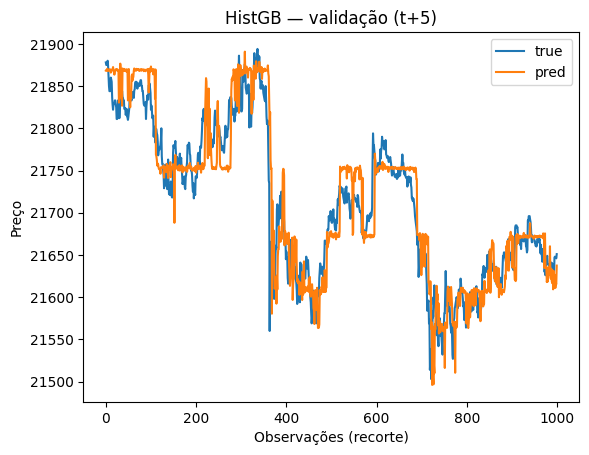

In [62]:
if "y_pred_valid_t5_A" in globals():
    plot_preds(y_valid_t5, y_pred_valid_t5_A, "HistGB — validação (t+5)")
else:
    print("HistGB (val) ainda não foi gerado.")


- Aqui o gráfico da predição acompanha bem direção geral da curva real, inclusie nas grandes variações, como quedas e subidas

- Também podemos analisar platôs em algumas seções que são típicas de modelos de árvore com boosting

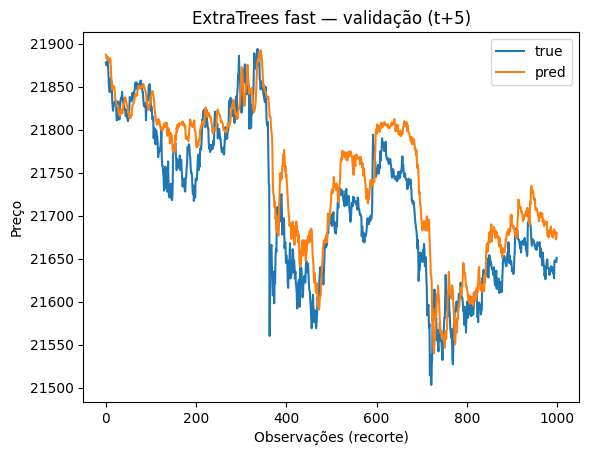

In [63]:
if "y_pred_valid_t5_BL" in globals():
    plot_preds(y_valid_t5, y_pred_valid_t5_BL, "ExtraTrees fast — validação (t+5)")
else:
    print("ExtraTrees (val) ainda não foi gerado.")


- No modelo B (ExtraTreesRegressor) vemos uma situação parecida de acompanhamento geral da curva real dos dados, mas nesse caso sem platôs

- Por outro lado temos um viés positivo, onde os preços tenderam a ser super estimados

- Em quedas grandes o modelo demora a reagir e subestima a amplitude da queda; árvores médias tendem a seguir a média e não extrapolar

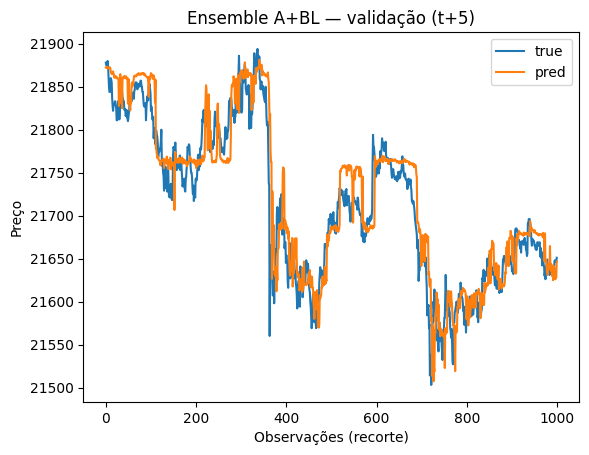

In [64]:
if "y_pred_valid_t5_ens_ABL" in globals() and y_pred_valid_t5_ens_ABL is not None:
    plot_preds(y_valid_t5, y_pred_valid_t5_ens_ABL, "Ensemble A+BL — validação (t+5)")
else:
    print("Ensemble A+BL (val) ainda não foi gerado.")


- Aqui a mistura de modelos também segue bem a direção geral da curva, mas herda os problemas dos dois modelos

- O ensemble reage tarde e subestima as curvas, igual o modelo B

- Os mesmos platôs do modelo A também são vistos aqui, mas um pouco suavizados

# 11. Tabela-resumo de métricas

In [65]:
metrics_df = pd.DataFrame(metrics).T.round(4)
display(metrics_df)

,MAE,RMSE,sMAPE
baseline_valid_t1,16.1868,30.6647,0.0384
baseline_test_t1,34.4535,56.4025,0.0402
HistGB_valid_t5,4143.7010,8448.5023,7.9050
HistGB_test_t5,40722.9419,45409.7537,56.6149
ET_fast_valid_t5,14978.7271,21331.8921,39.7014
ET_fast_test_t5,64274.2683,67340.9223,111.3035
Ensemble A+BL (ponderado)_valid_t5,6411.3097,10952.1002,13.4989
Ensemble A+BL (ponderado)_test_t5,45826.3553,50037.2506,66.7266


Aqui temos uma visão conjunta de todas as métricas gerados ao longo do notebook

# 12. Considerações Finais

- Acho que a primeira consideração e mais importante a ser feita é que independente dos resultados adquiridos com os modelos implementados esse trabalho além de focar na análise também teve um lado de como lidar com recursos limitados.

- O dataset escolhido, consistia em ~4,5 milhões de instâncias cada uma com 6 colunas, aproximadamente 27 milhões de valores a serem considerados durante os treinos dos modelos, tudo isso depois de um corte temporal que retirou ~5 anos de dados do conjunto

- Com isso os modelos foram criados em mente para serem treinados num tempo hábil e de forma que a RAM do collab não fosse excedida

- Além dos modelos usados tentei implementar algoritimos de RandomForestRegressor (com GridSearchCV e com RandomizedSearchCV), DecisionTreeRegressor, GradientBoostingRegressor e ExtraTreesRegressos (todos com tuning), porém tive que descartar todas essas tentativas por um tempo inviável de execução ou porque o limite de RAM do colab foi excedido. Também cogitei a implementação de um modelo ARIMA, mas depois das outras tentativas sabia que teria os mesmo problema.

- O modelo que apresentou o melhor resultado foi o *Histogram Gradient Boostin* com *early stoppin* e ao olhar as métricas mesmo do melhor modelo elas aparentam ser um pouco elevadas, porém ao fazer a análise gráfica dos dois modelos e do ensemble vemos um padrão de acompanhamento significativo dos dados reais, com alguns platôs e atrasos, mas sem grandes anomalias ou divergências significativas, (subiu quando deveria descer por exemplo)

- Feitas todas as considerações e analisado todos os resultados acho que alcancei um resultado satisfatório para os recursos disponíveis, é claro que se tratando de um problema que potencialmente involve investimentos financeiros a precisão e acurácia deveriam ser bem maiores, mas para isso foi constatado que é necessário um poder computacional bem maior.